# Data exploration with smaller file GDSC2_fitted_dose_response_27Oct23.xlsx

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_excel(r'C:\Users\Juli\Downloads\GDSC2_fitted_dose_response_27Oct23.xlsx')

In [5]:
df.head()

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [66]:
# Check if the same SANGER_MODEL_ID always has the same CANCER_TYPE
grouped = df.groupby('SANGER_MODEL_ID')['CANCER_TYPE'].nunique()
inconsistent = grouped[grouped > 1]

if len(inconsistent) > 0:
    print("There are SANGER_MODEL_ID with inconsistent CANCER_TYPE:")
    print(inconsistent)
else:
    print("All SANGER_MODEL_ID have consistent CANCER_TYPE.")

All SANGER_MODEL_ID have consistent CANCER_TYPE.


In [65]:
df.shape
df['SANGER_MODEL_ID'].is_unique

False

## Data Dictionary
| Field Name | Description |
|---|---|
| DATASET | Indicates the dataset name. Datasets are processed as a whole. |
| NLME_RESULT_ID | Identifier for the fitted results. (Nonlinear mixed effect models)|
| NLME_CURVE_ID | Identifier for the fitted dose response. |
| CELL_LINE_NAME | Model name. |
| SANGER_MODEL_ID | Sanger DepMap model identifier. |
| CANCER_TYPE | Sanger DepMap cancer type annotation. |
| DRUG_ID | Drug identifier. |
| DRUG_NAME | Primary drug name. |
| PUTATIVE_TARGET | Putative drug target. |
| PATHWAY_NAME | Pathway assigned to the putative drug target. |
| MIN_CONC | Minimum micromolar screening concentration of the drug within the dataset. |
| MAX_CONC | Maximum micromolar screening concentration of the drug within the dataset. |
| LN_IC50 | Natural log of the fitted IC50. |
| AUC | Area Under the Curve for the fitted model. Presented as a fraction of the total area between the highest and lowest screening concentration. -> Je kleiner die Fläche, desto stärker wirkt das Medikament. proxy for accuracy of IC50|
| RMSE | Root Mean Squared Error, a measurement of how well the modelled curve fits the data points. Curves with RMSE > 0.3 are excluded prior to release as part of quality control. |
| Z_SCORE | Z score of the LN_IC50 comparing it to the mean and standard deviation of the LN_IC50 values for the drug in question over all models treated. suitable measurement value for our drug screening response matrix as it corresponds to a normalization for each drug over all cell lines|

In [6]:
print(df.groupby('CANCER_TYPE').CANCER_TYPE.value_counts())
#print(df.groupby('DRUG_NAME').DRUG_NAME.value_counts())

CANCER_TYPE
Acute Myeloid Leukemia                 6934
B-Cell Non-Hodgkin's Lymphoma          8781
B-Lymphoblastic Leukemia               5143
Biliary Tract Carcinoma                1008
Bladder Carcinoma                      4724
Breast Carcinoma                      13388
Burkitt's Lymphoma                     3590
Cervical Carcinoma                     3531
Chondrosarcoma                         1439
Chronic Myelogenous Leukemia           2611
Colorectal Carcinoma                  12997
Endometrial Carcinoma                  2790
Esophageal Carcinoma                   2513
Esophageal Squamous Cell Carcinoma     6613
Ewing's Sarcoma                        6076
Gastric Carcinoma                      6897
Glioblastoma                           8796
Glioma                                 3205
Head and Neck Carcinoma                4139
Hepatocellular Carcinoma               4164
Hodgkin's Lymphoma                     1674
Kidney Carcinoma                       7462
Melanoma            

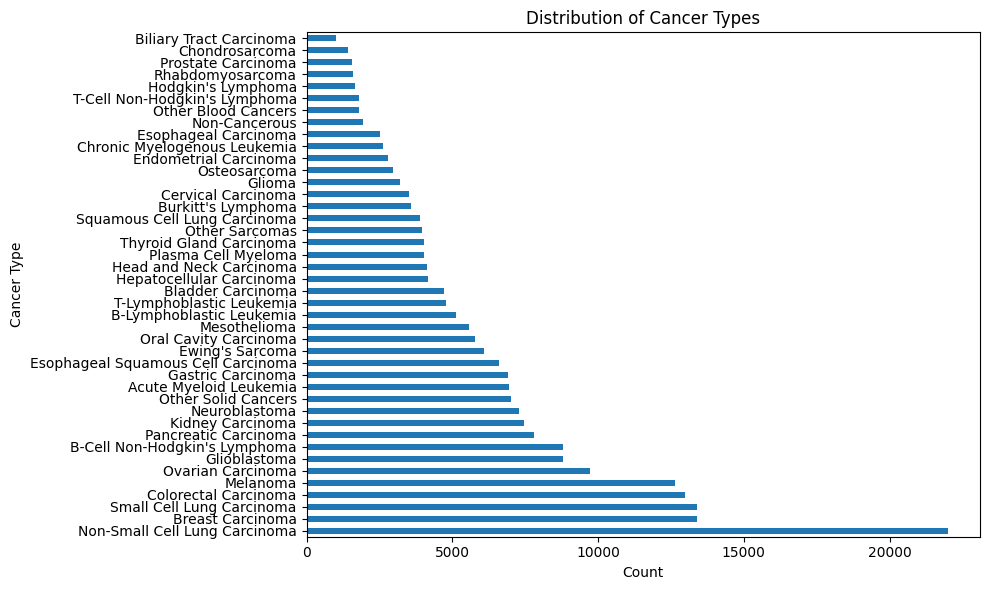

In [7]:
df_cancer_type_counts = df['CANCER_TYPE'].value_counts()
plt.figure(figsize=(10, 6))
df_cancer_type_counts.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Cancer Type')
plt.title('Distribution of Cancer Types')
plt.tight_layout()
plt.show()

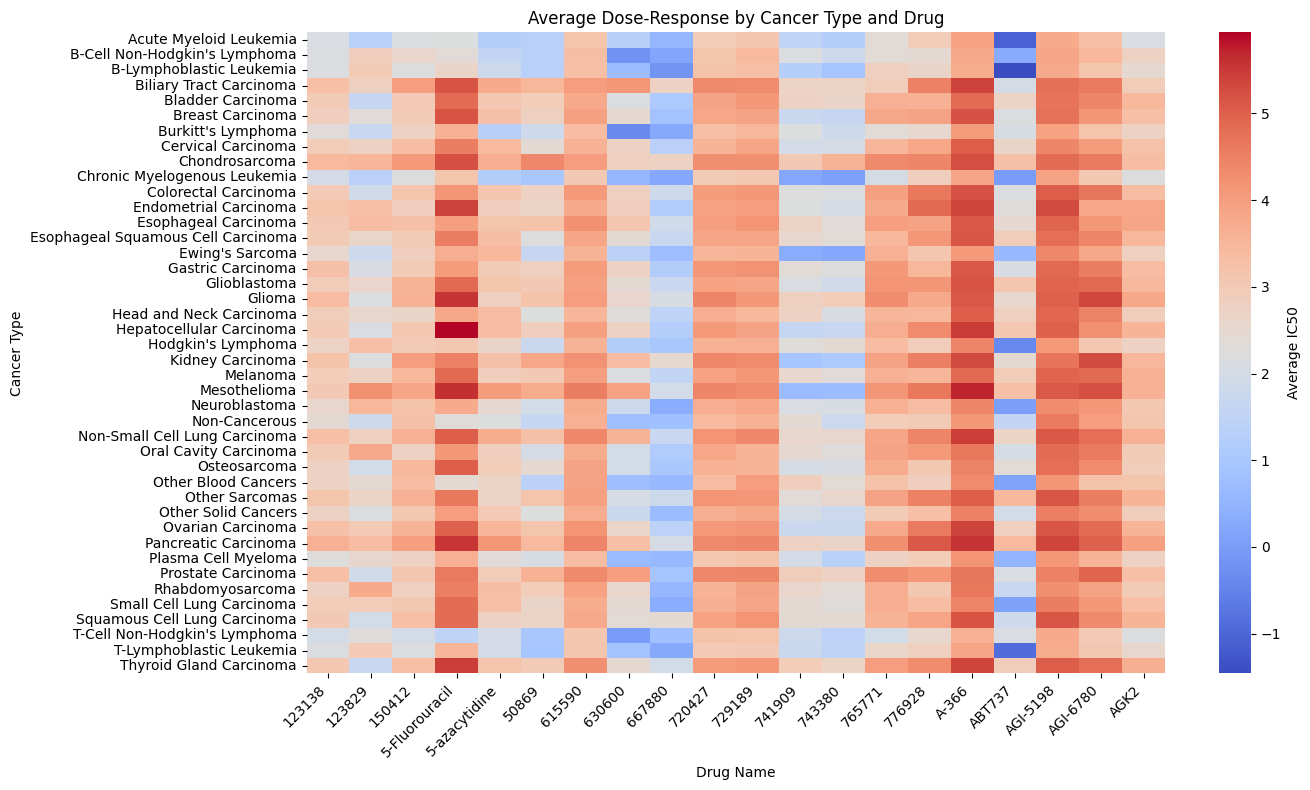

In [8]:
# Heatmap of Cancer Type vs Drug with average dose response
# Assumes there's a column like 'IC50' or similar dose-response metric
heatmap_data = df.pivot_table(values='LN_IC50', index='CANCER_TYPE', columns='DRUG_NAME', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data.iloc[:, :20], cmap='coolwarm', cbar_kws={'label': 'Average IC50'})
plt.xlabel('Drug Name')
plt.ylabel('Cancer Type')
plt.title('Average Dose-Response by Cancer Type and Drug')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

IC_50 is Half Maximal Inhibitory Concentration
- Concentration of the drug that is necessary to stop 50% of the cancer growth
- Logarithm tells us: blue means lower/negative values, so you just need a small drug dosis; red is analog
- for example the drug "ABT737" has many blue boxes, especially in combination with different types of leukemia
- there is also a "non-cancerous" category

## Pathways

In [4]:
print("All pathways:")
pathway_names = df['PATHWAY_NAME'].unique()
for pathway in pathway_names:
    print(f"  - {pathway}")

All pathways:
  - DNA replication
  - Mitosis
  - Other
  - EGFR signaling
  - Apoptosis regulation
  - Chromatin histone acetylation
  - ABL signaling
  - ERK MAPK signaling
  - PI3K/MTOR signaling
  - Genome integrity
  - Other, kinases
  - Protein stability and degradation
  - RTK signaling
  - Cell cycle
  - WNT signaling
  - JNK and p38 signaling
  - p53 pathway
  - Cytoskeleton
  - IGF1R signaling
  - Hormone-related
  - Chromatin histone methylation
  - Metabolism
  - Chromatin other
  - Unclassified


## Z-Score

Z_SCORE ANALYSIS

Summary Statistics:
count    2.420360e+05
mean     7.312962e-10
std      9.993925e-01
min     -8.254501e+00
25%     -6.568485e-01
50%      1.058000e-02
75%      6.560362e-01
max      7.978776e+00
Name: Z_SCORE, dtype: float64

Distribution by Drug:
                       mean  std       min       max  count
DRUG_NAME                                                  
CHIR-99021     5.333333e-08  1.0 -2.834820  2.207374    225
GSK2256098C    2.789400e-08  1.0 -2.969008  3.247915    717
Pictilisib     2.585315e-08  1.0 -3.642957  4.302347    967
AZD5582        2.497162e-08  1.0 -3.579402  2.608372    881
AZD5438        2.370990e-08  1.0 -2.323220  3.887613    717
PF-4708671     2.238806e-08  1.0 -3.570390  3.139934    268
Entospletinib  2.237136e-08  1.0 -3.350541  3.320673    894
GSK2830371A    2.092050e-08  1.0 -3.947121  2.947519    717
THR-101        2.051984e-08  1.0 -3.958271  2.886245    731
729189         1.952580e-08  1.0 -4.169217  3.920063    717


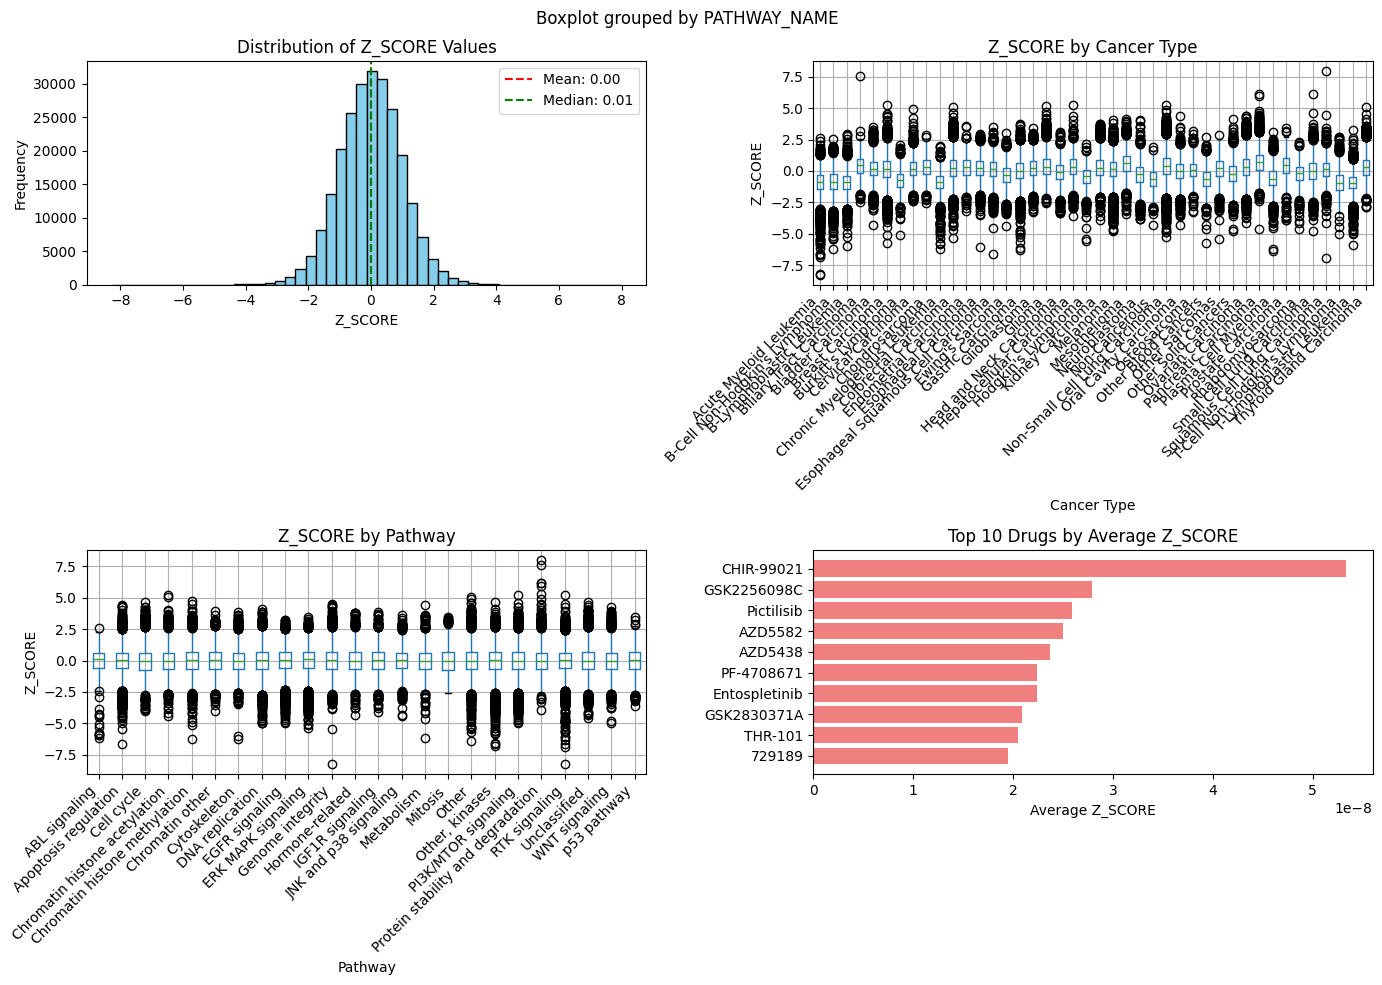

In [5]:
# Z_SCORE Summary Statistics
print("=" * 60)
print("Z_SCORE ANALYSIS")
print("=" * 60)
print("\nSummary Statistics:")
print(df['Z_SCORE'].describe())

print("\n" + "=" * 60)
print("Distribution by Drug:")
print("=" * 60)
drug_z_stats = df.groupby('DRUG_NAME')['Z_SCORE'].agg(['mean', 'std', 'min', 'max', 'count'])
print(drug_z_stats.sort_values('mean', ascending=False).head(10))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of Z_SCORE
axes[0, 0].hist(df['Z_SCORE'], bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('Z_SCORE')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Z_SCORE Values')
axes[0, 0].axvline(df['Z_SCORE'].mean(), color='red', linestyle='--', label=f'Mean: {df["Z_SCORE"].mean():.2f}')
axes[0, 0].axvline(df['Z_SCORE'].median(), color='green', linestyle='--', label=f'Median: {df["Z_SCORE"].median():.2f}')
axes[0, 0].legend()

# 2. Box plot by Cancer Type
df.boxplot(column='Z_SCORE', by='CANCER_TYPE', ax=axes[0, 1])
axes[0, 1].set_title('Z_SCORE by Cancer Type')
axes[0, 1].set_xlabel('Cancer Type')
axes[0, 1].set_ylabel('Z_SCORE')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')

# 3. Box plot by Pathway
df.boxplot(column='Z_SCORE', by='PATHWAY_NAME', ax=axes[1, 0])
axes[1, 0].set_title('Z_SCORE by Pathway')
axes[1, 0].set_xlabel('Pathway')
axes[1, 0].set_ylabel('Z_SCORE')
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# 4. Top drugs by average Z_SCORE
top_drugs = df.groupby('DRUG_NAME')['Z_SCORE'].mean().sort_values(ascending=False).head(10)
axes[1, 1].barh(range(len(top_drugs)), top_drugs.values, color='lightcoral')
axes[1, 1].set_yticks(range(len(top_drugs)))
axes[1, 1].set_yticklabels(top_drugs.index)
axes[1, 1].set_xlabel('Average Z_SCORE')
axes[1, 1].set_title('Top 10 Drugs by Average Z_SCORE')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## Harmonize data

This is a public dataset regarding gene expression. Just trying. 

In [118]:
ge = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv", index_col=0)

Metadata describing all cancer models/cell lines which are referenced by a dataset contained within the DepMap portal

In [75]:
metadata = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Model.csv", usecols=['ModelID', 'COSMICID', 'SangerModelID', 'ModelIDAlias'])
metadata.rename(columns={'SangerModelID': 'SANGER_MODEL_ID'}, inplace=True)

In [13]:
df.head()

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [78]:
metadata.head()

,ModelID,SANGER_MODEL_ID,COSMICID,ModelIDAlias
0,ACH-000001,SIDM00105,905933.0,NaN
1,ACH-000002,SIDM00829,905938.0,NaN
2,ACH-000003,SIDM00891,NaN,NaN
3,ACH-000004,SIDM00594,907053.0,NaN
4,ACH-000005,SIDM00593,NaN,NaN


In [119]:
ge['ModelConditionID'].is_unique

False

## L1000 landmark geneset

In [4]:
L1000 = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\L1000.txt", sep='\t')

- ID = Entrez Gene ID for the feature
- spot_id = 24nt unique molecular barcode tagged per gene bead
- pr_analyte_id = Full name of the Luminex analyte used to measure the feature
- pr_analyte_num = Integer index of the Luminex analyte used to measure the feature
- pr_bset_id = Set of beads (beadset) that was used to measure this feature (2 beadsets are used to make the duplex measurement, allowing the ~1000 features to be measured using the 500 distinct analytes
- pr_gene_symbol = HUGO gene symbol for the feature
- sequence = 20nt gene-specific fragment

In [10]:
L1000.head()

,ID,spot_id,pr_analyte_id,pr_analyte_num,pr_bset_id,pr_gene_symbol,sequence
0,5720,LUA-3404,Analyte 11,11,dp52,PSME1,ACATCCGGCTGATGGTCATGGAGATCCGCAATGCTTATGC
1,55847,LUA-3431,Analyte 12,12,dp52,CISD1,ACCACCTCTGTCTGATTCACCTTCGCTGGATTCTAAATGT
2,25803,LUA-1326,Analyte 13,13,dp52,SPDEF,CCCCTGAGTTGGGCAGCCAGGAGTGCCCCCGGGAATGGAT
3,466,LUA-3660,Analyte 14,14,dp52,ATF1,TTCAGATTGGCTAATATTTGCATTGTAAATTTTGTATGCA
4,6009,LUA-3487,Analyte 15,15,dp52,RHEB,AGAAAAAATGGACGGGGCAGCTTCACAAGGCAAGTCTTCA


In [181]:
import re

# Extract Entrez IDs from ge column names like "TSPAN6 (7105)"
ge_col2id = {}
for col in ge.columns:
    match = re.search(r"\((\d+)\)\s*$", col)
    if match:
        ge_col2id[col] = int(match.group(1))

# Normalize L1000 IDs to integers and filter
L1000_ids = set(pd.to_numeric(L1000['ID'], errors='coerce').dropna().astype(int))
valid_ge_cols = [col for col, entrez in ge_col2id.items() if entrez in L1000_ids]

# New dataframe containing only matching columns
ge_matched = ge[['SequencingID', 'ModelID', 'IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC'] + valid_ge_cols].copy()
print(f"Selected {len(valid_ge_cols)} matching columns out of {len(ge.columns)} total ge columns and saving it in ge_matched.")
ge_matched.head()

Selected 978 matching columns out of 19220 total ge columns and saving it in ge_matched.


,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),...,TWF2 (11344),HOXA10 (3206),LYN (4067),CHMP4A (29082),POLG2 (11232),RBM15B (29890),MRPL12 (6182),IKBKE (9641),DUSP14 (11072),PIP4K2B (8396)
0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,4.956577,3.179411,5.585888,4.856592,4.772382,...,3.881244,0.000000,3.227964,6.106993,5.376176,3.781716,5.136060,0.109694,5.508574,4.871706
1,CDS-02TzJp,ACH-001289,Yes,MC-001289-BpdI,Yes,4.954992,2.783576,6.156599,6.250399,4.671135,...,4.852119,0.728105,1.672380,6.519867,4.233543,4.201579,5.594133,0.785037,5.485163,4.834484
2,CDS-0693hw,ACH-001339,Yes,MC-001339-5nRN,Yes,3.421952,2.615880,5.096717,6.269129,4.636549,...,5.359300,5.015306,2.780102,5.620372,3.471266,3.439807,6.475904,2.395142,5.904340,4.273322
3,CDS-07Plat,ACH-001619,No,MC-001619-IR6I,No,5.196729,2.144996,5.558329,4.844245,3.838508,...,4.122225,4.336676,3.525104,5.518346,3.973556,3.831816,7.464897,2.988021,5.422105,4.581984
4,CDS-08FOcu,ACH-001979,Yes,MC-001979-E3qW,Yes,4.651643,2.454515,5.053415,7.138825,4.414575,...,4.981935,0.000000,2.447391,6.384074,2.434762,3.957525,4.427103,2.109839,5.237908,4.540963


In [184]:
ge_matched.head()

,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),...,LYN (4067),CHMP4A (29082),POLG2 (11232),RBM15B (29890),MRPL12 (6182),IKBKE (9641),DUSP14 (11072),PIP4K2B (8396),SANGER_MODEL_ID,CANCER_TYPE
0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,4.956577,3.179411,5.585888,4.856592,4.772382,...,3.227964,6.106993,5.376176,3.781716,5.136060,0.109694,5.508574,4.871706,SIDM01226,Unknown
1,CDS-02TzJp,ACH-001289,Yes,MC-001289-BpdI,Yes,4.954992,2.783576,6.156599,6.250399,4.671135,...,1.672380,6.519867,4.233543,4.201579,5.594133,0.785037,5.485163,4.834484,NaN,Unknown
2,CDS-0693hw,ACH-001339,Yes,MC-001339-5nRN,Yes,3.421952,2.615880,5.096717,6.269129,4.636549,...,2.780102,5.620372,3.471266,3.439807,6.475904,2.395142,5.904340,4.273322,SIDM00514,Unknown
3,CDS-07Plat,ACH-001619,No,MC-001619-IR6I,No,5.196729,2.144996,5.558329,4.844245,3.838508,...,3.525104,5.518346,3.973556,3.831816,7.464897,2.988021,5.422105,4.581984,NaN,Unknown
4,CDS-08FOcu,ACH-001979,Yes,MC-001979-E3qW,Yes,4.651643,2.454515,5.053415,7.138825,4.414575,...,2.447391,6.384074,2.434762,3.957525,4.427103,2.109839,5.237908,4.540963,NaN,Unknown


In [183]:
# Schritt A: Nur die Zeilen aus den Metadaten nehmen, die wirklich eine Brücke haben
mapping_bridge = metadata[['ModelID', 'SANGER_MODEL_ID']].dropna(subset=['SANGER_MODEL_ID'])

# Schritt B: Merge die Brücke an deine Gendaten
# Wir löschen eine eventuell vorhandene kaputte SANGER_MODEL_ID Spalte vorher
if 'SANGER_MODEL_ID' in ge_matched.columns:
    ge_matched = ge_matched.drop(columns=['SANGER_MODEL_ID'])

ge_matched = pd.merge(ge_matched, mapping_bridge, on='ModelID', how='left')

# Schritt C: Jetzt den CANCER_TYPE holen
cancer_info = df[['SANGER_MODEL_ID', 'CANCER_TYPE']].drop_duplicates()
ge_matched = pd.merge(ge_matched, cancer_info, on='SANGER_MODEL_ID', how='left')

# Schritt D: SICHERHEITS-CHECK gegen den KeyError
if 'CANCER_TYPE' in ge_matched.columns:
    ge_matched['CANCER_TYPE'] = ge_matched['CANCER_TYPE'].fillna('Unknown')
    print("CANCER_TYPE was added successfully.")
else:
    # Falls der Merge gar nichts gefunden hat, erstellen wir die Spalte manuell
    ge_matched['CANCER_TYPE'] = 'Unknown'
    print("No matches found; CANCER_TYPE set to 'Unknown'.")

CANCER_TYPE was added successfully.


In [185]:
print(ge_matched.shape)
ge_matched.SANGER_MODEL_ID


(1754, 985)


0       SIDM01226
1             NaN
2       SIDM00514
3             NaN
4             NaN
          ...    
1749          NaN
1750    SIDM00275
1751          NaN
1752          NaN
1753    SIDM00848
Name: SANGER_MODEL_ID, Length: 1754, dtype: object

In [195]:
# Count NaN values in SANGER_MODEL_ID
nan_count = ge_matched['SANGER_MODEL_ID'].isna().sum()
print(f"Number of NaN values in ge_matched.SANGER_MODEL_ID: {nan_count}, so {nan_count/ge_matched.shape[0]:.2%} of the rows have NaN SANGER_MODEL_ID.")

Number of NaN values in ge_matched.SANGER_MODEL_ID: 840, so 47.89% of the rows have NaN SANGER_MODEL_ID.


In [193]:
# delete columns that we don't use
ge_matched = ge_matched.drop(columns=['IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC'])

## Big merge with complete drug data

In [ ]:
# Selection of relevant columns from drug dataframe (df)
# need id to merge + target values (labels)
drug_data_cols = [
    'SANGER_MODEL_ID', 'DRUG_ID', 'DRUG_NAME', 
    'LN_IC50', 'Z_SCORE', 'RMSE', 'AUC'
]
df_subset = df[drug_data_cols]

# merge, only keep rows where we have both gene expression data AND drug response data
master_df = pd.merge(ge_matched, df_subset, on='SANGER_MODEL_ID', how='inner')

# check results
print(f"Dimension of the new master df: {master_df.shape}")
print(f"Unique drugs: {master_df['DRUG_NAME'].nunique()}")
print(f"Unique cell lines: {master_df['SANGER_MODEL_ID'].nunique()}")

Dimension of the new master df: (186550, 988)
Unique drugs: 286
Unique cell lines: 715


In [198]:
master_df.head()

,SequencingID,ModelID,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),CASP10 (843),CFLAR (8837),FKBP4 (2288),...,DUSP14 (11072),PIP4K2B (8396),SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,LN_IC50,Z_SCORE,RMSE,AUC
0,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1003,Camptothecin,-2.963191,-0.383200,0.094466,0.821438
1,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1004,Vinblastine,-4.023106,-0.244142,0.122361,0.712813
2,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1005,Cisplatin,2.848175,-0.203192,0.108946,0.938878
3,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1006,Cytarabine,2.218343,0.292158,0.117640,0.953169
4,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1007,Docetaxel,-4.240700,0.074531,0.070175,0.884847


Now I look for the SMILES codes for each drug

In [202]:
import pubchempy as pcp

# get unique drugs
#unique_drugs = master_df[['DRUG_ID', 'DRUG_NAME']].drop_duplicates()
unique_drugs = master_df[['DRUG_NAME']].drop_duplicates()

def get_smiles(name):
    try:
        # Suche nach dem Namen in PubChem
        compound = pcp.get_compounds(name, 'name')[0]
        return compound.canonical_smiles
    except:
        return None

# 2. SMILES abrufen (das kann einen Moment dauern)
print("Look for SMILES in PubChem...")
unique_drugs['SMILES'] = unique_drugs['DRUG_NAME'].apply(get_smiles)


Look for SMILES in PubChem...


C:\Users\Juli\AppData\Local\Temp\ipykernel_5100\2718603952.py:11: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  return compound.canonical_smiles


In [204]:
# 3. map smiles in master df
smiles_map = unique_drugs.set_index('DRUG_NAME')['SMILES'].to_dict()
master_df['SMILES'] = master_df['DRUG_NAME'].map(smiles_map)

In [205]:
master_df.head()

,SequencingID,ModelID,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),CASP10 (843),CFLAR (8837),FKBP4 (2288),...,PIP4K2B (8396),SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,LN_IC50,Z_SCORE,RMSE,AUC,SMILES
0,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,4.235061,SIDM01085,Bladder Carcinoma,1003,Camptothecin,-2.963191,-0.383200,0.094466,0.821438,CCC1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3...
1,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,4.235061,SIDM01085,Bladder Carcinoma,1004,Vinblastine,-4.023106,-0.244142,0.122361,0.712813,CCC1(CC2CC(C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(...
2,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,4.235061,SIDM01085,Bladder Carcinoma,1005,Cisplatin,2.848175,-0.203192,0.108946,0.938878,N.N.Cl[Pt]Cl
3,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,4.235061,SIDM01085,Bladder Carcinoma,1006,Cytarabine,2.218343,0.292158,0.117640,0.953169,C1=CN(C(=O)N=C1N)C2C(C(C(O2)CO)O)O
4,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,4.235061,SIDM01085,Bladder Carcinoma,1007,Docetaxel,-4.240700,0.074531,0.070175,0.884847,CC1=C2C(C(=O)C3(C(CC4C(C3C(C(C2(C)C)(CC1OC(=O)...


In [ ]:
#master_df.to_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\harmonised_data.csv", index=False)

### Visualize the relationship between gene expression and drug response using t-SNE

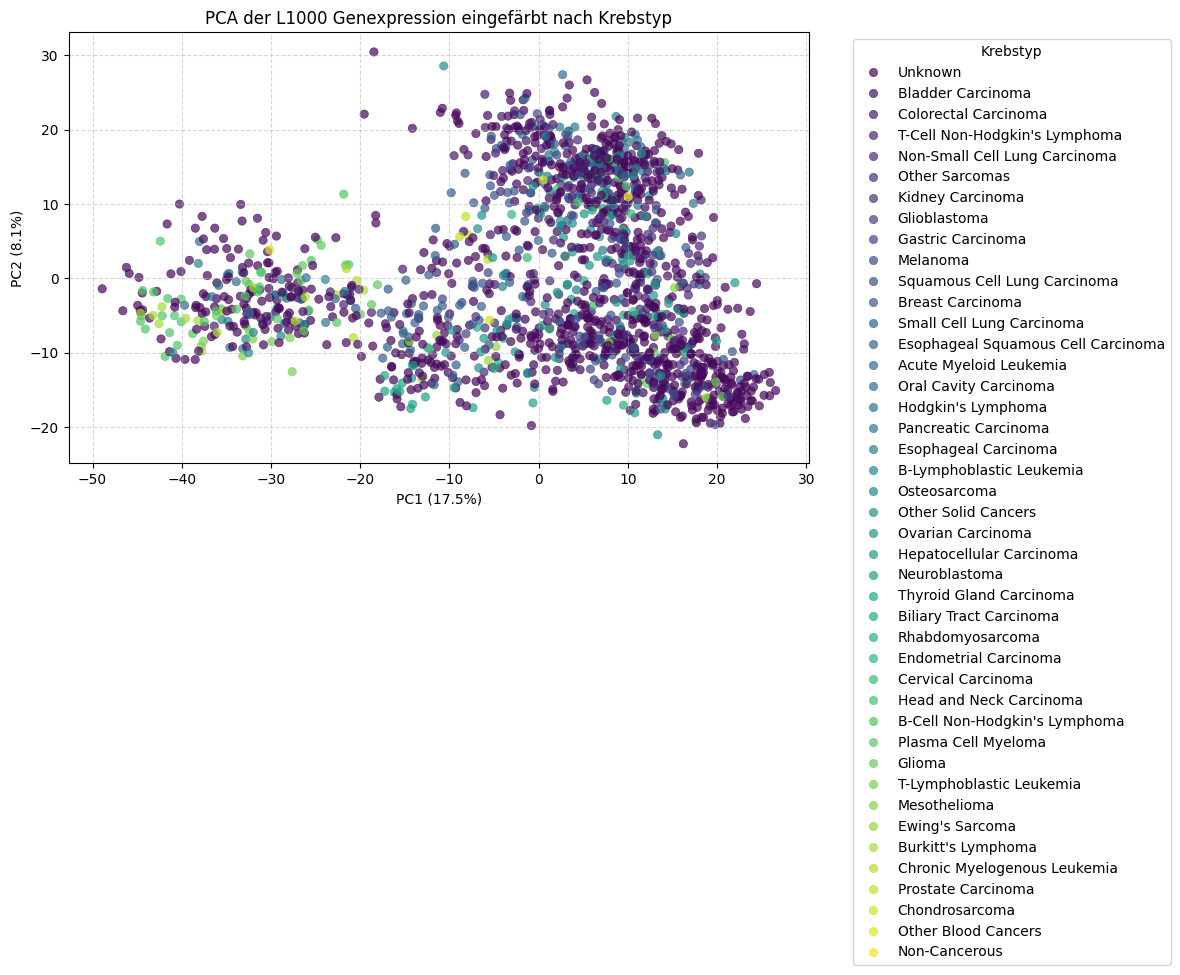

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. PCA vorbereiten (nur auf den Gen-Spalten, meistens die ersten 978)
# Achte darauf, dass du nur numerische Daten nimmst!
gene_columns = ge_matched.columns[5:983] 
pca = PCA(n_components=2)
pca_results = pca.fit_transform(ge_matched[gene_columns])

# 2. Ergebnisse in ein temporäres DataFrame für das Plotten speichern
pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
pca_df['Cancer Type'] = ge_matched['CANCER_TYPE'].values

# 3. Den Plot erstellen
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cancer Type', 
    data=pca_df, 
    palette='viridis', # oder 'tab20' für viele verschiedene Farben
    alpha=0.7,
    edgecolor=None
)

# Achsen-Beschriftung mit erklärter Varianz
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("PCA der L1000 Genexpression eingefärbt nach Krebstyp")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Krebstyp')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

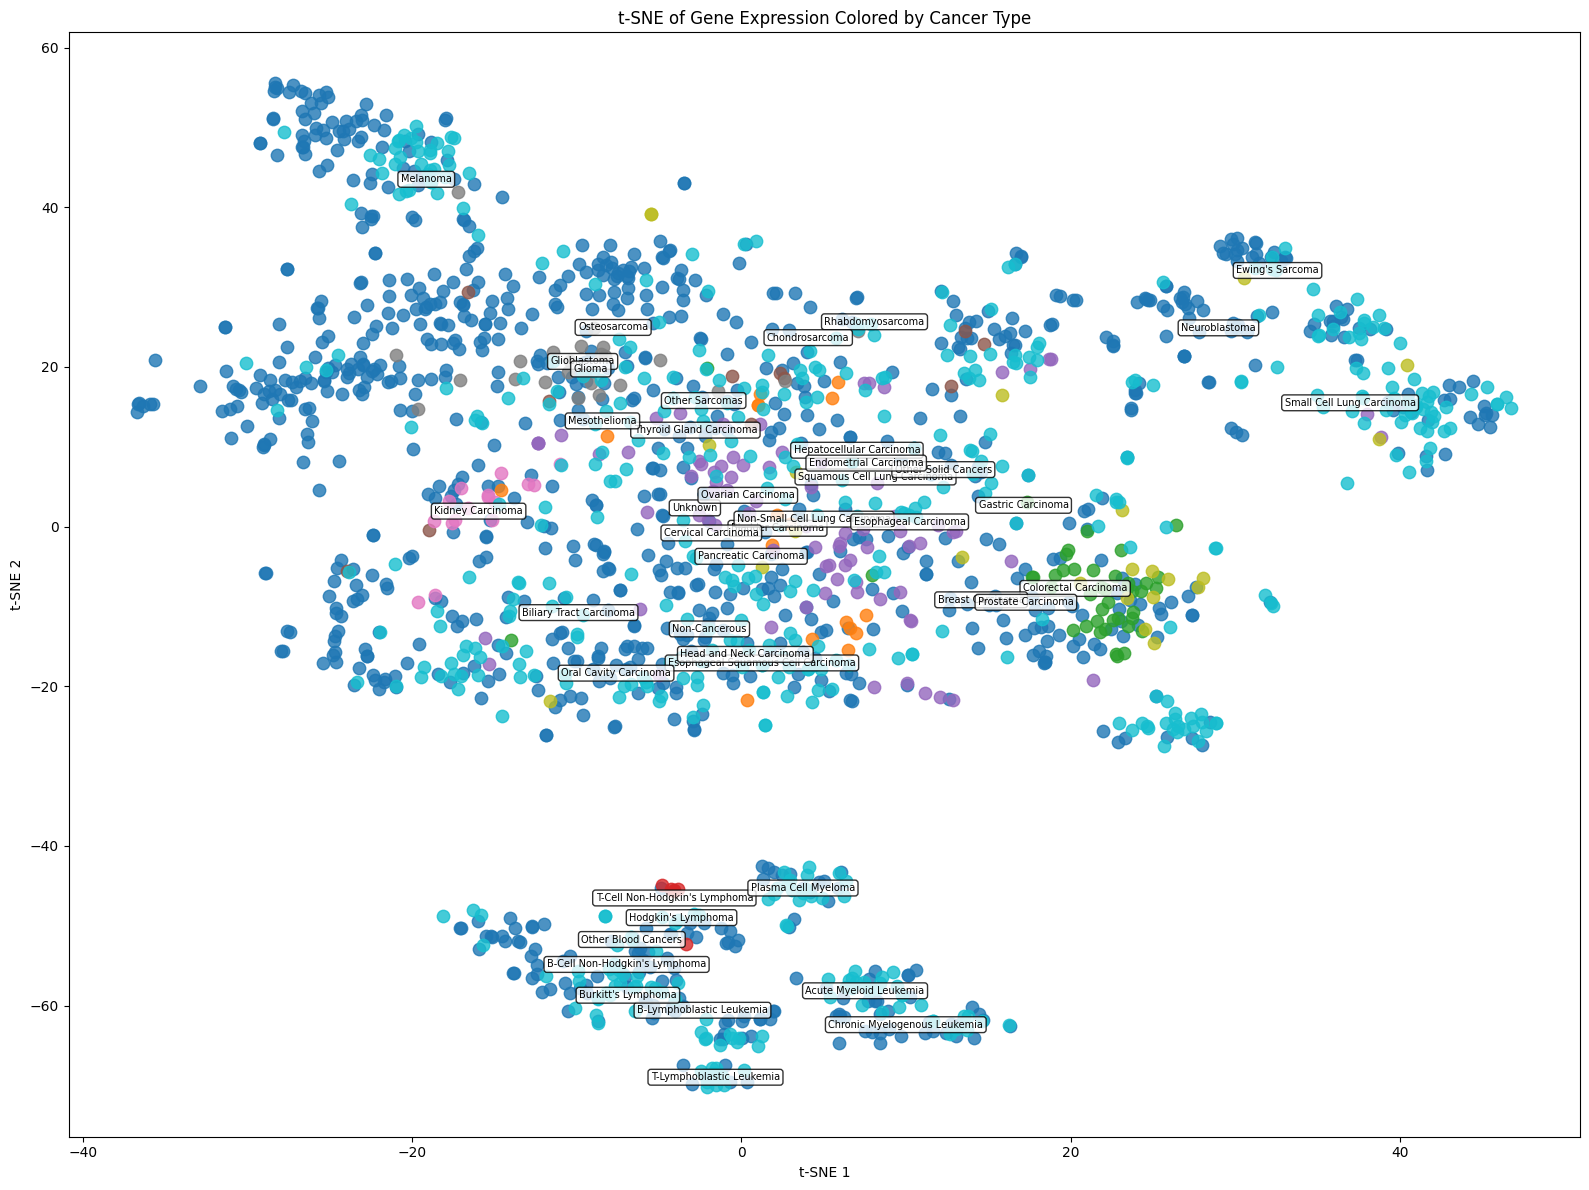

In [53]:
# Compute t-SNE embedding
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(scaled_data)

plt.figure(figsize=(16, 12))
unique_cancers = cancer_types.unique()
colors = plt.cm.tab10(range(len(unique_cancers)))
for i, cancer in enumerate(unique_cancers):
    mask = cancer_types == cancer
    if mask.sum() == 0:
        continue
    plt.scatter(tsne_result[mask, 0], tsne_result[mask, 1], label=cancer, alpha=0.8, s=80, color=colors[i])

    # Add label at the mean position of the group
    mean_x = tsne_result[mask, 0].mean()
    mean_y = tsne_result[mask, 1].mean()
    plt.text(mean_x, mean_y, cancer, fontsize=7, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.title('t-SNE of Gene Expression Colored by Cancer Type')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
if len(unique_cancers) <= 15:
    plt.legend(loc='upper right', fontsize='small', framealpha=0.8)
plt.tight_layout()
plt.show()

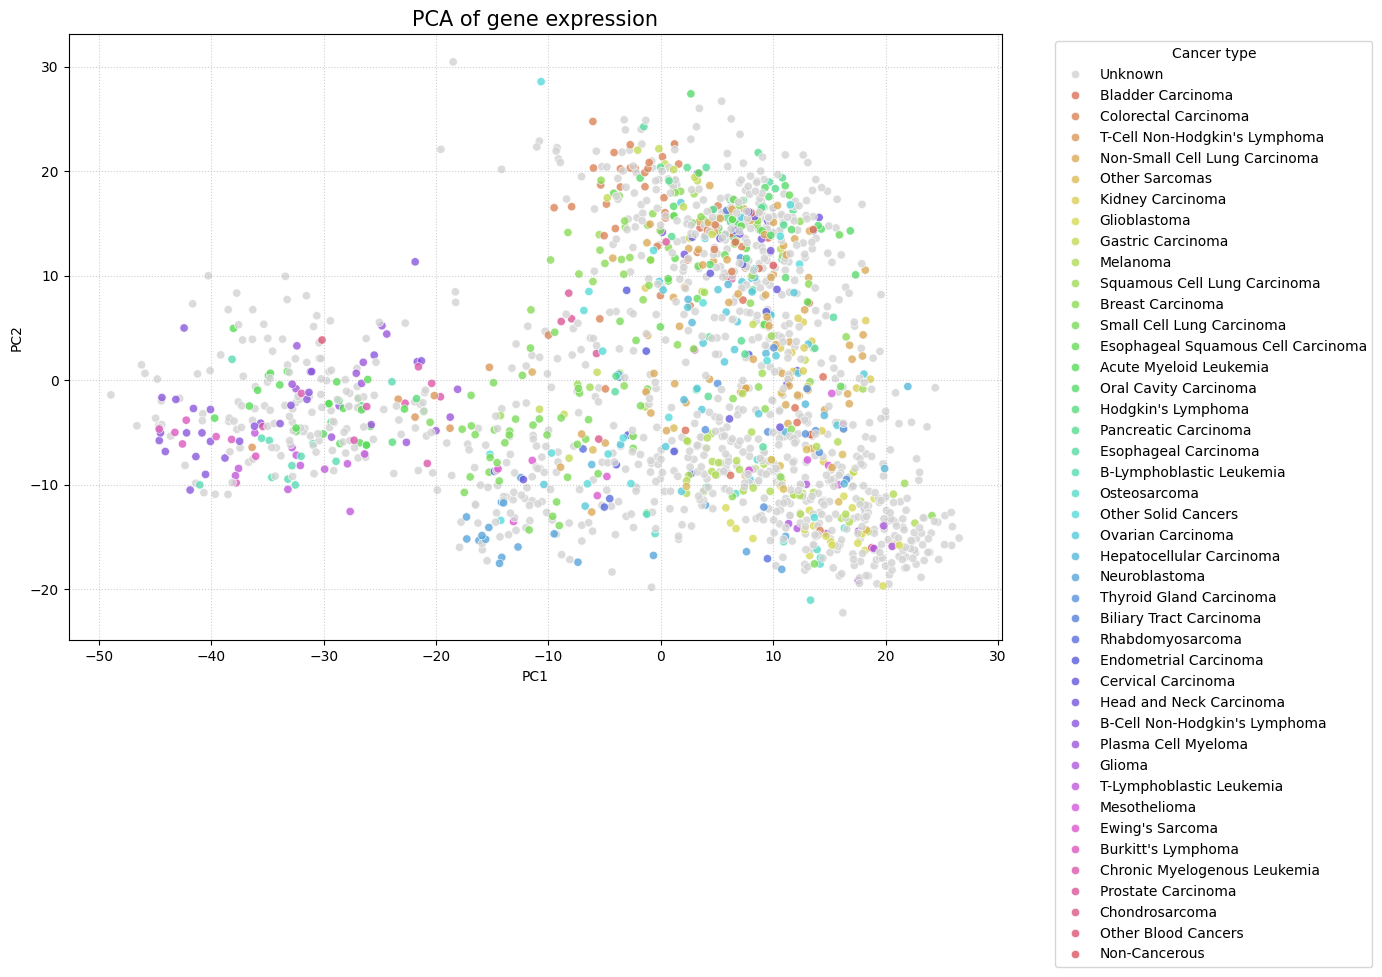

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vorbereitung: Alle einzigartigen Krebstypen finden
unique_types = pca_df['Cancer Type'].unique()

# 2. Eine Farbpalette erstellen
# Wir nehmen 'tab20' oder 'hls' für die Buntheit und überschreiben dann 'Unknown'
colors = sns.color_palette("hls", len(unique_types))
palette = dict(zip(unique_types, colors))

# 3. Explizit 'Unknown' auf Grau setzen
if 'Unknown' in palette:
    palette['Unknown'] = '#d3d3d3' # Ein helles Grau

# 4. Den Plot erstellen
plt.figure(figsize=(14, 9))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cancer Type', 
    data=pca_df, 
    palette=palette,  # Hier nutzen wir unsere benutzerdefinierte Palette
    alpha=0.8,
    edgecolor='w',    # Ein feiner weißer Rand hilft bei überlappenden Punkten
    linewidth=0.5
)

# Optisches Finetuning
plt.title("PCA of gene expression", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cancer type')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()